In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.pipeline import *
from src.models.neural_models import HybridGRU_LSTM

# EDA and Visualizations

In [3]:
data=pd.read_csv('./data/processed/final_dataset_with_indicators.csv')
data.head()

,Unnamed: 0,Date,HVO_class_II_fob_ARA,Ucome_fob_ARA,UCO_exw_ARA,EU_BRENT_CRUDE,LSMGO_Rotterdam,EUR_USD_rate,Rate,FuelEU_MGO_penalty,...,LSMGO_Rotterdam_KST,LSMGO_Rotterdam_PSL,LSMGO_Rotterdam_MSTD_20,LSMGO_Rotterdam_MVAR_20,LSMGO_Rotterdam_BB_Upper,LSMGO_Rotterdam_BB_Lower,LSMGO_Rotterdam_BB_Middle,LSMGO_Rotterdam_KER_20,LSMGO_Rotterdam_DMA_20_50,LSMGO_Rotterdam_MAD_20
0,0,2021-04-26,1965.05,1568.95,1310.390,65.65,503.0,0.8280,0.07,0.0,...,0.0,0.000000,NaN,NaN,NaN,NaN,503.000000,0.0,0.0,0.0
1,1,2021-04-27,1968.09,1591.75,1310.390,66.42,516.0,0.8280,0.07,0.0,...,0.0,8.333333,9.192388,84.500000,527.884776,491.115224,509.500000,0.0,0.0,0.0
2,2,2021-04-28,1982.93,1605.45,1312.605,67.27,521.0,0.8266,0.07,0.0,...,0.0,16.666667,9.291573,86.333333,531.916480,494.750187,513.333333,0.0,0.0,0.0
3,3,2021-04-29,1987.52,1607.19,1320.735,68.56,528.0,0.8253,0.06,0.0,...,0.0,25.000000,10.551461,111.333333,538.102922,495.897078,517.000000,0.0,0.0,0.0
4,4,2021-04-30,1983.18,1609.77,1311.200,67.25,523.0,0.8313,0.05,0.0,...,0.0,25.000000,9.523655,90.700000,537.247310,499.152690,518.200000,0.0,0.0,0.0


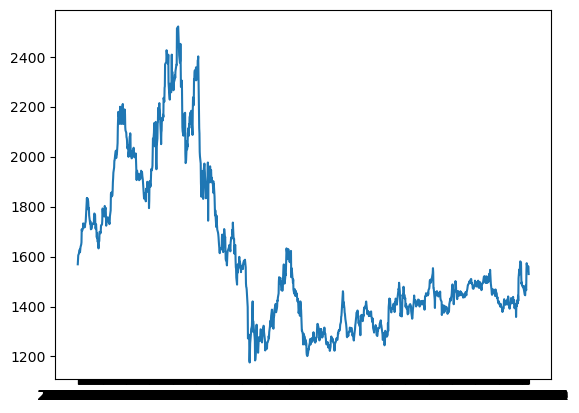

In [4]:
plt.plot(data['Date'], data['Ucome_fob_ARA']);

{'whiskers': [<matplotlib.lines.Line2D at 0x1299d3811d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1299d381450>,
 'boxes': [<matplotlib.lines.Line2D at 0x1299d381090>],
 'medians': [<matplotlib.lines.Line2D at 0x1299d3816d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1299d381810>],
 'means': []}

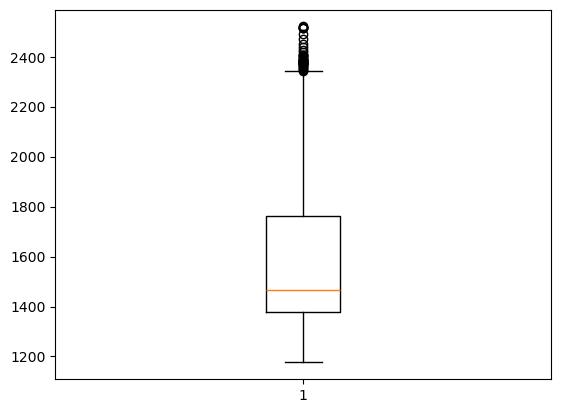

In [5]:
plt.boxplot(data['Ucome_fob_ARA'])

# Model Training Example

In [6]:
scaled_data = data_scaler('MinMax')

Calculating Indicators for HVO_class_II_fob_ARA
Calculating Indicators for Ucome_fob_ARA
Calculating Indicators for UCO_exw_ARA
Calculating Indicators for EU_BRENT_CRUDE
Calculating Indicators for LSMGO_Rotterdam

All 26 technical indicators calculated successfully!

Indicators added (130) total columns:

DataFrame shape: (1824, 139)


d:\Github\ML-Final-Project\src\feature_engine.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_price_df[f'{column}_BB_Upper'] = stock['boll_ub']  # Bollinger Band Upper
d:\Github\ML-Final-Project\src\feature_engine.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_price_df[f'{column}_BB_Lower'] = stock['boll_lb']  # Bollinger Band Lower
d:\Github\ML-Final-Project\src\feature_engine.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

In [7]:
target_col = scaled_data['Ucome_fob_ARA']

In [ ]:

#new stuff
scaled_data, selected_cols = select_features_rf(scaled_data, top_n=40)

n_features = scaled_data.shape[1]  # Number of features (price + indicators)

train_data, test_data = train_test_split(scaled_data)
window_size = 30
lookahead_value = 10
batch_size = 32

best_params = optimize_hyperparameters(
    train_df=train_data, 
    lookahead_value=lookahead_value, 
    batch_size=batch_size, 
    n_features=n_features
)
windowed_train = window_creator(train_data, best_params['window_size'], lookahead_value, batch_size)

windowed_test = window_creator(test_data, best_params['window_size'], lookahead_value, batch_size)

Ucome_fob_ARA_KAMA_10           0.995360
Ucome_fob_ARA_Stochastic_RSI    0.000980
Ucome_fob_ARA_RSI_14            0.000630
UCO_exw_ARA_MAD_20              0.000093
EU_BRENT_CRUDE_BB_Upper         0.000093
Ucome_fob_ARA_MACD_Histogram    0.000082
Ucome_fob_ARA_RoC_12            0.000076
Ucome_fob_ARA_PSL               0.000068
Ucome_fob_ARA_LRMA_20           0.000068
EU_BRENT_CRUDE_MACD             0.000064
dtype: float64

--- Starting Hyperparameter Optimization ---
Tested: GRU=67, LSTM=108, Drop=0.17, LR=0.0036, Window=30 --> Mean Val Loss: 0.016777
Tested: GRU=118, LSTM=98, Drop=0.14, LR=0.0008, Window=45 --> Mean Val Loss: 0.013659
Tested: GRU=119, LSTM=39, Drop=0.36, LR=0.0001, Window=33 --> Mean Val Loss: 0.048973
Tested: GRU=123, LSTM=45, Drop=0.18, LR=0.0002, Window=30 --> Mean Val Loss: 0.042584
Tested: GRU=48, LSTM=91, Drop=0.34, LR=0.0001, Window=34 --> Mean Val Loss: 0.065606
Tested: GRU=64, LSTM=39, Drop=0.17, LR=0.0001, Window=42 --> Mean Val Loss: 0.025822
Tested: GRU=72,

In [15]:
windowed_train = window_creator(train_data, best_params['window_size'], lookahead_value, batch_size)

windowed_test = window_creator(test_data, best_params['window_size'], lookahead_value, batch_size)

In [16]:
model = HybridGRU_LSTM(
    gru_units=int(best_params['gru_units']),
    lstm_units=int(best_params['lstm_units']),
    dropout=float(best_params['dropout']),
    learning_rate=float(best_params['learning_rate']),
    window_size=best_params['window_size'],
    n_features=n_features
)

In [19]:
print("Training model on training set...")
history = model.train(windowed_train)  # train_data contains (X, y) pairs internally
print("Training complete!\n")
 
print("Evaluating model on test set...")
test_metrics = model.evaluate(windowed_test)  # test_data contains (X, y) pairs internally
print(f"Test Loss (MSE): {test_metrics[0]:.6f}")
print(f"Test MAE: {test_metrics[1]:.6f}\n")
    
print("Generating predictions on test set...")
predictions = model.predict(windowed_test)
print(f"Predictions shape: {predictions.shape}")
print(f"First 10 predictions:\n{predictions[:10].flatten()}")
print(f"Prediction range: [{predictions.min():.4f}, {predictions.max():.4f}]")
    
print("\nModel training and evaluation complete!")

Training model on training set...
Training complete!

Evaluating model on test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0019 - mae: 0.0362
Test Loss (MSE): 0.001894
Test MAE: 0.036195

Generating predictions on test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predictions shape: (303, 1)
First 10 predictions:
[0.24496582 0.24532089 0.24561878 0.24587272 0.24615753 0.2463778
 0.2464601  0.24641992 0.24632438 0.24602655]
Prediction range: [0.2407, 0.2481]

Model training and evaluation complete!
